# Loss Given Default

Recall that we had the following formula: $$ECL=PD\cdot LGD \cdot EAD.$$ We have already trained a model to estimate $PD$. Now, we move onto $LGD$ (loss given default). The loss given a default assumes that a default has occurred, it is the fraction of the outstanding loan balance that is lost when the borrower defaults, after accounting for any recoveries. As such, we are only interested in loans that have defaulted for this section.

Let us first do our imports. Let us also load the original sample from before feature engineering, as we require the details of the loan.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

#load the original sample as df_raw (we need recovery columns dropped in 02)
df_raw = pd.read_csv('data/sample.csv', index_col=0)
print(df_raw.shape)

#check the relevant columns exist
print(df_raw[['loan_amnt', 'funded_amnt', 'recoveries', 'total_rec_prncp', 'default_flag']].head(10))

(99996, 152)
         loan_amnt  funded_amnt  recoveries  total_rec_prncp  default_flag
392949     32000.0      32000.0         0.0         24818.09             0
1273506     9600.0       9600.0         0.0          9600.00             0
324024      4000.0       4000.0         0.0          4000.00             0
2066630     6025.0       6025.0         0.0          6025.00             0
477199     25000.0      25000.0         0.0          3045.86             0
1975547    20000.0      20000.0         0.0         20000.00             0
302723      1000.0       1000.0         0.0          1000.00             0
1972188    24575.0      24575.0         0.0         24575.00             0
2251549     7000.0       7000.0         0.0          7000.00             0
641990     16000.0      16000.0         0.0         16000.00             0


So we have the required columns. We are only interested in those who defaulted, so we filter.

In [12]:
#filter to defaulted loans
df_defaults = df_raw[df_raw['default_flag'] == 1].copy()
print(f'Number of defaulted loans: {len(df_defaults)}')

Number of defaulted loans: 13221


We can compute the recovery rate for each loan, i.e. the proportion of recovered losses to the outstanding loan (which we first compute). The LGD is then $1$ less recovery rate.

We compute the LGD for each loan, then output the average. We will also output the average recovery rate.

In [13]:
#calculate outstanding balance at default
df_defaults['outstanding_balance'] = df_defaults['funded_amnt']-df_defaults['total_rec_prncp']

#LGD is the proportion of outstanding balance lost after recoveries
df_defaults['recovery_rate'] = df_defaults['recoveries']/df_defaults['outstanding_balance']
df_defaults['recovery_rate'] = df_defaults['recovery_rate'].clip(0, 1)
df_defaults['lgd'] = 1 - df_defaults['recovery_rate']

print(f'Mean recovery rate: {df_defaults["recovery_rate"].mean():.3f}')
print(f'Mean LGD: {df_defaults["lgd"].mean():.3f}')
print(f'Median LGD: {df_defaults["lgd"].median():.3f}')

Mean recovery rate: 0.102
Mean LGD: 0.898
Median LGD: 0.901


The average LGD is very high. This suggests that most defaulted loans are left mostly unrecovered, which is to be expected from consumer credit. Let us plot this output.

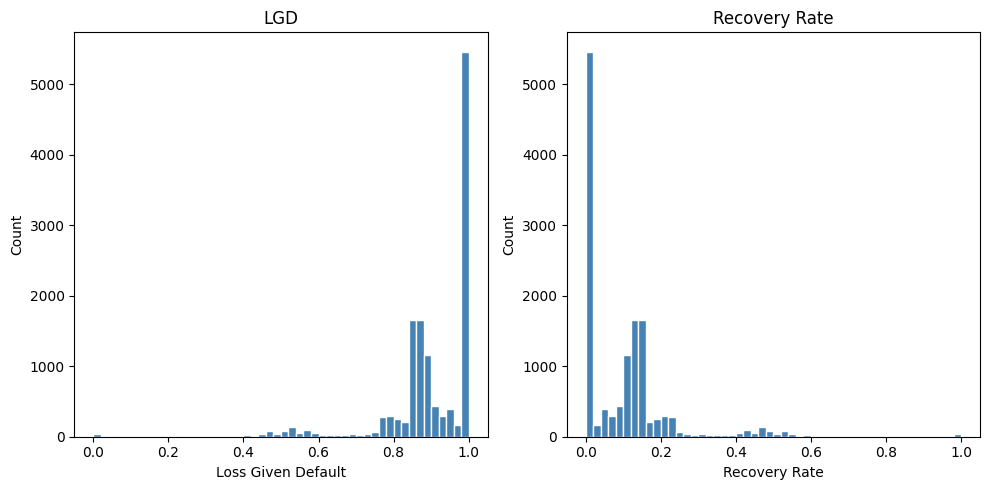

In [14]:
plt.figure(figsize=(10, 5))

#plot lgd
plt.subplot(1, 2, 1)
plt.hist(df_defaults['lgd'], bins=50, color='steelblue', edgecolor='white')
plt.xlabel('Loss Given Default')
plt.ylabel('Count')
plt.title('LGD')

#plot recovery rate
plt.subplot(1, 2, 2)
plt.hist(df_defaults['recovery_rate'], bins=50, color='steelblue', edgecolor='white')
plt.xlabel('Recovery Rate')
plt.ylabel('Count')
plt.title('Recovery Rate')

plt.tight_layout()
plt.show()

We see that most loans are fully written off, i.e. no recoveries are made. When recoveries are made, they are often between $10\%$-$20\%$ of the outstanding amount.

The concentration of the LGD to one value presents an issue. A standard linear regression will not work properly here due to the lack of continuous distribution (boundary problem). We must make a decision as to whether to use a fixed LGD value or a two-stage model that first identifies if any of the loan is recovered, then uses a model based on the given recovery rates (not including those at $0\%$) to estimate the LGD. We choose the former, for the following reasons:
- LendingClub loans are unsecured. There is no collateral to speak of.
- It is wiser to be conservative with LGD estimates, to avoid underestimating losses.
- It does not create additional model risk.
- There is a very minimal sample of defaulted loans with recoveries to build a model on.

So we choose our fixed LGD to be the mean LGD as calculated previously.

In [15]:
#we choose the LGD to be the mean
LGD = df_defaults["lgd"].mean()

print(f'Fixed LGD assumption: {LGD}')
print(f'Rounded: {df_defaults["lgd"].mean():.3f}')

#save LGD assumption
lgd_output = pd.DataFrame({'lgd': [LGD]})
lgd_output.to_csv('data/lgd.csv', index=False)

Fixed LGD assumption: 0.8983604426200285
Rounded: 0.898
